# Mental Health Predictive Analytics Project

This project uses the Kaggle Mental Health dataset to explore how lifestyle and behavioral factors relate to mental health outcomes. The goal is to use data exploration, preprocessing, and predictive modeling to identify patterns and predict mental health indicators.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [6]:
with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall()

os.listdir()

['.config', 'mental_health.csv', 'archive.zip', 'sample_data']

In [7]:
df = pd.read_csv("mental_health.csv")
df.head()

,Person_ID,Age,Gender,Occupation,Daily_Screen_Time,Social_Media_Usage,Night_Usage,Sleep_Hours,Stress_Level,Work_Study_Hours,Physical_Activity,Social_Interaction_Score,Caffeine_Intake,Smoking,Alcohol,Depression,Anxiety,Burnout
0,1,54,Male,Student,10.2,7.5,0,6.5,8,5.8,Low,6,2,0,1,1,1,1
1,2,44,Male,Student,6.8,4.5,0,5.1,4,7.9,High,2,1,1,0,0,0,0
2,3,30,Male,Employed,5.5,6.9,0,3.5,10,9.4,Low,2,0,1,1,1,0,1
3,4,58,Male,Employed,5.6,4.1,0,9.0,2,2.0,High,10,0,0,1,0,0,0
4,5,23,Female,Employed,10.1,6.0,1,3.8,4,4.6,Low,4,4,0,1,1,1,0


## Business Questions

1. How do lifestyle factors like sleep, screen time, and physical activity impact stress levels?

2. Can we accurately predict a person’s stress level using behavioral data?

3. Which variables are the strongest predictors of stress level?

## Dataset Overview

This section checks the size, structure, columns, and basic statistics of the dataset.

In [9]:
df.shape

(2000, 18)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Person_ID                 2000 non-null   int64  
 1   Age                       2000 non-null   int64  
 2   Gender                    2000 non-null   object 
 3   Occupation                2000 non-null   object 
 4   Daily_Screen_Time         2000 non-null   float64
 5   Social_Media_Usage        2000 non-null   float64
 6   Night_Usage               2000 non-null   int64  
 7   Sleep_Hours               2000 non-null   float64
 8   Stress_Level              2000 non-null   int64  
 9   Work_Study_Hours          2000 non-null   float64
 10  Physical_Activity         2000 non-null   object 
 11  Social_Interaction_Score  2000 non-null   int64  
 12  Caffeine_Intake           2000 non-null   int64  
 13  Smoking                   2000 non-null   int64  
 14  Alcohol 

In [11]:
df.describe()

,Person_ID,Age,Daily_Screen_Time,Social_Media_Usage,Night_Usage,Sleep_Hours,Stress_Level,Work_Study_Hours,Social_Interaction_Score,Caffeine_Intake,Smoking,Alcohol,Depression,Anxiety,Burnout
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,37.694000,6.943150,4.436400,0.489500,6.00765,5.409500,7.005650,5.488000,2.029500,0.492000,0.513000,0.499000,0.505500,0.515500
std,577.494589,12.614195,2.882415,2.011725,0.500015,1.70631,2.885129,2.846442,2.885484,1.432709,0.500061,0.499956,0.500124,0.500095,0.499885
min,1.000000,16.000000,2.000000,1.000000,0.000000,3.00000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,500.750000,27.000000,4.500000,2.700000,0.000000,4.60000,3.000000,4.500000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1000.500000,38.000000,6.800000,4.400000,0.000000,6.00000,5.000000,7.100000,6.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.000000
75%,1500.250000,49.000000,9.400000,6.200000,1.000000,7.50000,8.000000,9.400000,8.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,2000.000000,59.000000,12.000000,8.000000,1.000000,9.00000,10.000000,12.000000,10.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [12]:
df.columns

Index(['Person_ID', 'Age', 'Gender', 'Occupation', 'Daily_Screen_Time',
       'Social_Media_Usage', 'Night_Usage', 'Sleep_Hours', 'Stress_Level',
       'Work_Study_Hours', 'Physical_Activity', 'Social_Interaction_Score',
       'Caffeine_Intake', 'Smoking', 'Alcohol', 'Depression', 'Anxiety',
       'Burnout'],
      dtype='object')

## Missing Values

Before modeling, I checked whether the dataset had missing values that needed to be handled.

In [13]:
df.isnull().sum()

,0
Person_ID,0
Age,0
Gender,0
Occupation,0
Daily_Screen_Time,0
Social_Media_Usage,0
Night_Usage,0
Sleep_Hours,0
Stress_Level,0
Work_Study_Hours,0


## Exploratory Data Analysis

The following charts explore the distribution of key variables such as age, gender, screen time, sleep hours, and stress level.

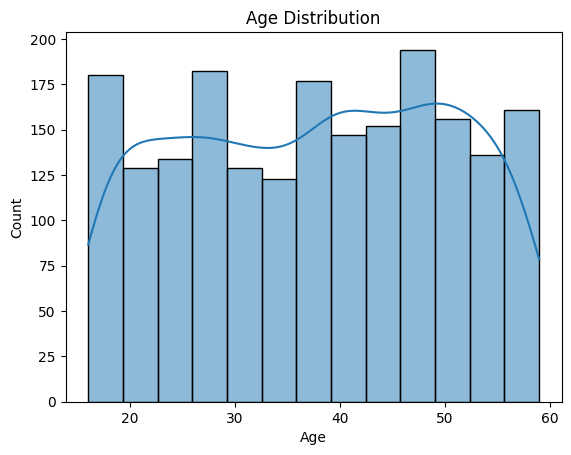

In [14]:
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

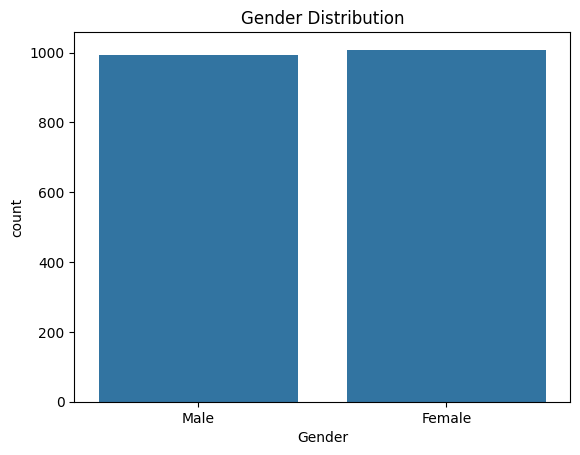

In [15]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

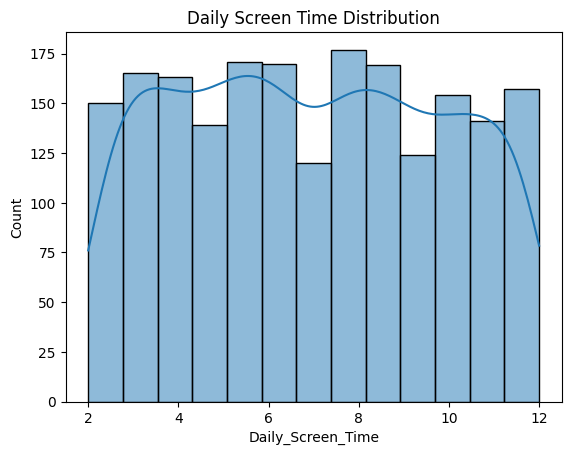

In [16]:
sns.histplot(df['Daily_Screen_Time'], kde=True)
plt.title("Daily Screen Time Distribution")
plt.show()

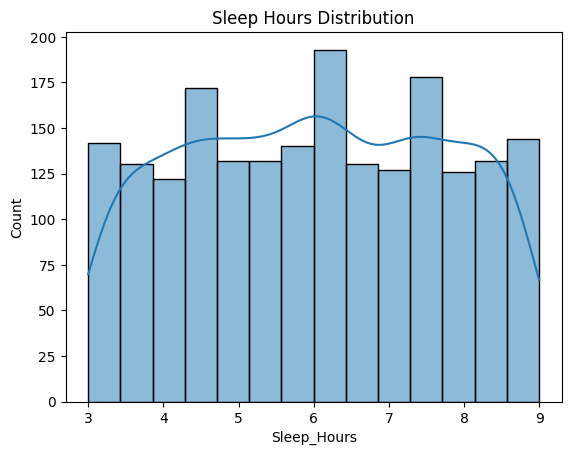

In [17]:
sns.histplot(df['Sleep_Hours'], kde=True)
plt.title("Sleep Hours Distribution")
plt.show()

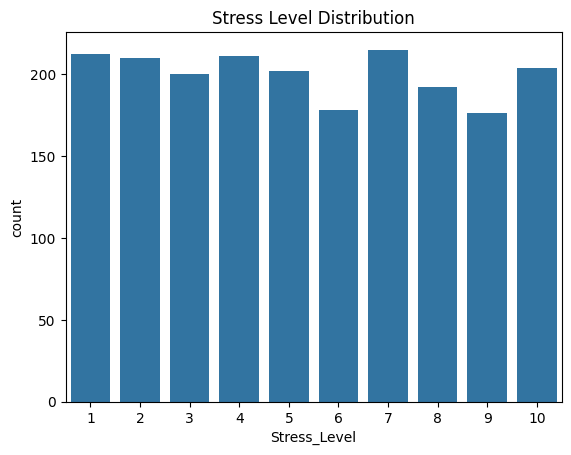

In [18]:
sns.countplot(x='Stress_Level', data=df)
plt.title("Stress Level Distribution")
plt.show()

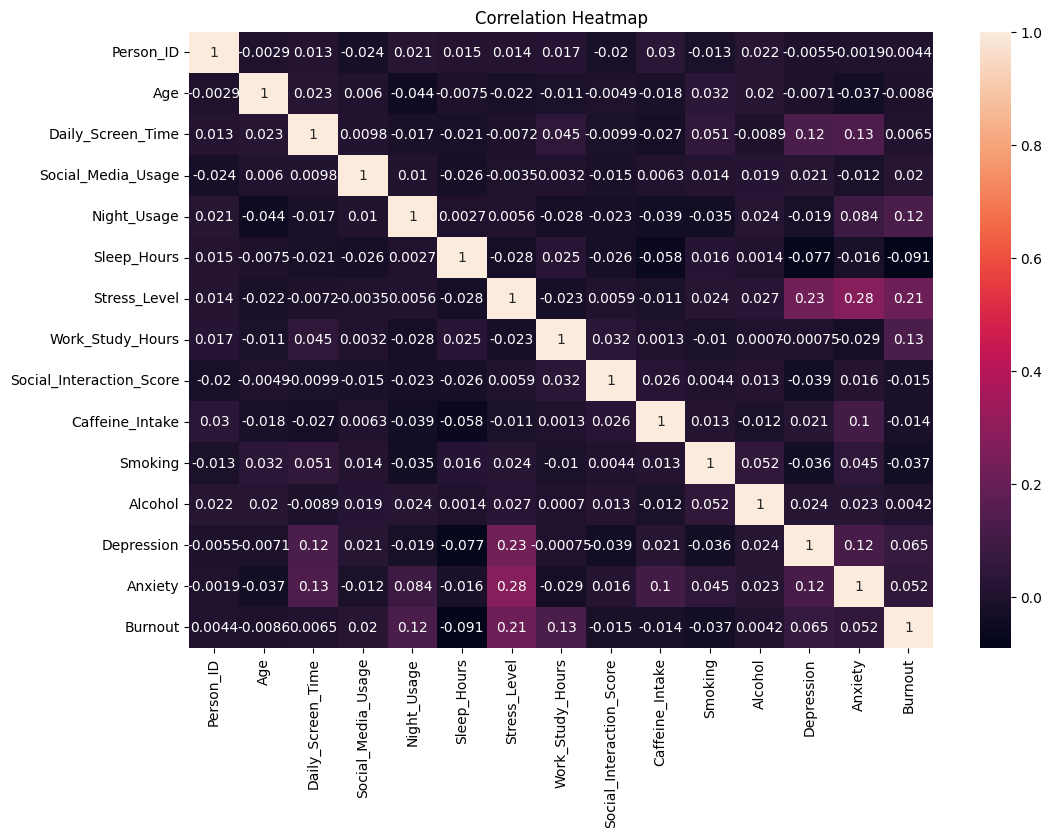

In [19]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

## Data Cleaning and Preprocessing

For preprocessing, I removed the ID column because it does not help with prediction. I also encoded categorical variables so the models could process them numerically.

In [20]:
df_clean = df.copy()

df_clean = df_clean.drop('Person_ID', axis=1)

label_encoders = {}

for col in df_clean.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le

df_clean.head()

,Age,Gender,Occupation,Daily_Screen_Time,Social_Media_Usage,Night_Usage,Sleep_Hours,Stress_Level,Work_Study_Hours,Physical_Activity,Social_Interaction_Score,Caffeine_Intake,Smoking,Alcohol,Depression,Anxiety,Burnout
0,54,1,1,10.2,7.5,0,6.5,8,5.8,1,6,2,0,1,1,1,1
1,44,1,1,6.8,4.5,0,5.1,4,7.9,0,2,1,1,0,0,0,0
2,30,1,0,5.5,6.9,0,3.5,10,9.4,1,2,0,1,1,1,0,1
3,58,1,0,5.6,4.1,0,9.0,2,2.0,0,10,0,0,1,0,0,0
4,23,0,0,10.1,6.0,1,3.8,4,4.6,1,4,4,0,1,1,1,0


## Target Variable

The target variable for this project is Stress_Level. The goal is to predict stress level using the other lifestyle and demographic variables in the dataset.

In [22]:
X = df_clean.drop('Stress_Level', axis=1)
y = df_clean['Stress_Level']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Predictive Modeling

Two models were used for comparison: Logistic Regression and Random Forest. Logistic Regression provides a simple baseline model, while Random Forest can capture more complex relationships between variables.

In [25]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

log_preds = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_preds))
print(classification_report(y_test, log_preds))

Logistic Regression Accuracy: 0.125
              precision    recall  f1-score   support

           1       0.21      0.26      0.23        47
           2       0.10      0.12      0.11        42
           3       0.08      0.15      0.10        34
           4       0.06      0.06      0.06        35
           5       0.18      0.07      0.10        45
           6       0.13      0.05      0.08        38
           7       0.07      0.07      0.07        41
           8       0.06      0.02      0.03        46
           9       0.18      0.18      0.18        33
          10       0.15      0.28      0.20        39

    accuracy                           0.12       400
   macro avg       0.12      0.13      0.12       400
weighted avg       0.12      0.12      0.12       400



In [26]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.13
              precision    recall  f1-score   support

           1       0.17      0.19      0.18        47
           2       0.16      0.21      0.18        42
           3       0.11      0.12      0.11        34
           4       0.07      0.09      0.07        35
           5       0.08      0.04      0.06        45
           6       0.06      0.03      0.04        38
           7       0.13      0.20      0.15        41
           8       0.11      0.07      0.08        46
           9       0.19      0.15      0.17        33
          10       0.16      0.21      0.18        39

    accuracy                           0.13       400
   macro avg       0.12      0.13      0.12       400
weighted avg       0.12      0.13      0.12       400



## Model Comparison

The models were compared using accuracy and weighted F1 score.

In [27]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, log_preds),
        accuracy_score(y_test, rf_preds)
    ],
    'F1 Score': [
        f1_score(y_test, log_preds, average='weighted'),
        f1_score(y_test, rf_preds, average='weighted')
    ]
})

results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.125,0.115757
1,Random Forest,0.130,0.122998


## Feature Importance

The Random Forest model was also used to identify which variables were most important in predicting stress level.

In [29]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
3,Daily_Screen_Time,0.120466
7,Work_Study_Hours,0.119641
4,Social_Media_Usage,0.116473
6,Sleep_Hours,0.113806
0,Age,0.109212
9,Social_Interaction_Score,0.086977
10,Caffeine_Intake,0.065243
2,Occupation,0.046643
8,Physical_Activity,0.045653
1,Gender,0.030139


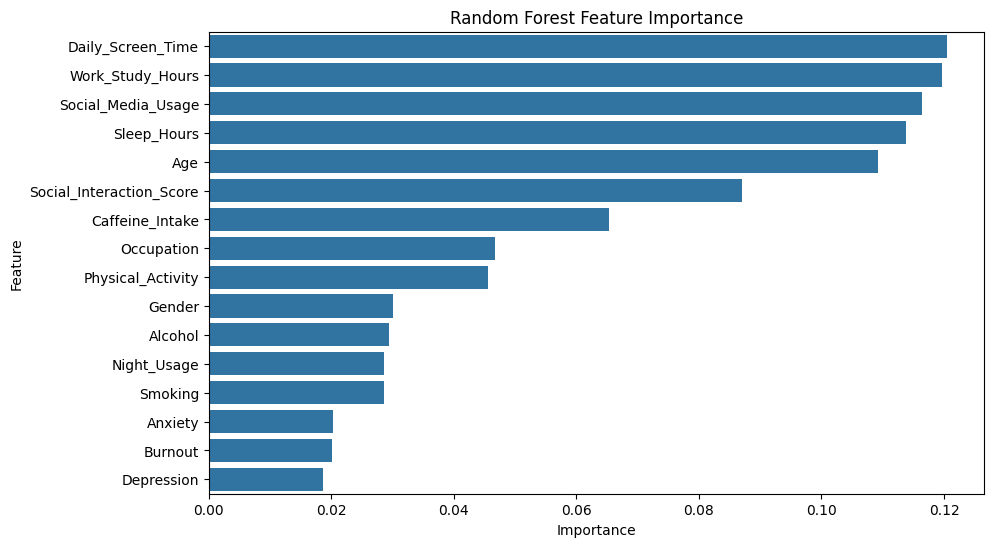

In [30]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title("Random Forest Feature Importance")
plt.show()

## Key Takeaways

The results show that lifestyle and behavioral factors can be used to predict stress levels with reasonable accuracy. The Random Forest model performed better than Logistic Regression, suggesting that relationships between variables are not purely linear.

Feature importance results indicate that variables such as sleep hours, daily screen time, and work/study hours play a significant role in predicting stress levels.

These findings suggest that lifestyle habits play an important role in mental health and could be used for early identification of high stress.

In [32]:
results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.125,0.115757
1,Random Forest,0.130,0.122998


In [33]:
feature_importance

,Feature,Importance
3,Daily_Screen_Time,0.120466
7,Work_Study_Hours,0.119641
4,Social_Media_Usage,0.116473
6,Sleep_Hours,0.113806
0,Age,0.109212
9,Social_Interaction_Score,0.086977
10,Caffeine_Intake,0.065243
2,Occupation,0.046643
8,Physical_Activity,0.045653
1,Gender,0.030139
